## Imports

In [72]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import LinearNDInterpolator

## Open all files

In [73]:
df_dict = {}
directory = 'processed_data/'
for filename in os.listdir(directory):
    if not filename.endswith('endurance.csv'):
        filepath = os.path.join(directory, filename)
        df_dict[filename] = pd.read_csv(filepath)

## Attempting to calculate controller efficiency ($\eta_{c}$)

### Available Variables:
- $I_{motor}$

- $V_{controller}$

- $V_{tractive}$

- $V_{battery}$

- $I_{battery}$

- $\omega_m$

- $\tau_m$

Using these variables, we can find the efficiency of the motor controller at every instant through the equation: $$\frac{\omega_m \times \tau_m}{I_{battery} \times V_{controller}} = \eta_c \times \eta_m = \eta_{dt}$$ This can be cross-referenced via: $$\frac{I_{motor} \times V_{controller}}{I_{battery} \times V_{controller}} = \eta_c \times \eta_m= \eta_{dt}$$ **Note: Motor current is not in Amps and must be converted before cross-referencing.**

Motor RPM is converted to rad/s through: $$\frac{RPM \times 2\pi}{60}$$ The code below performs the functions outlined above.

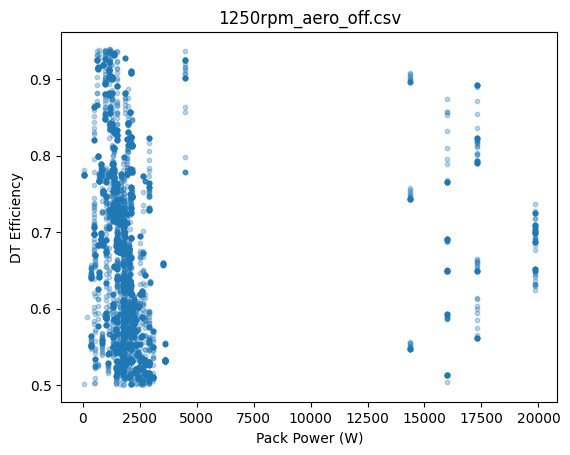

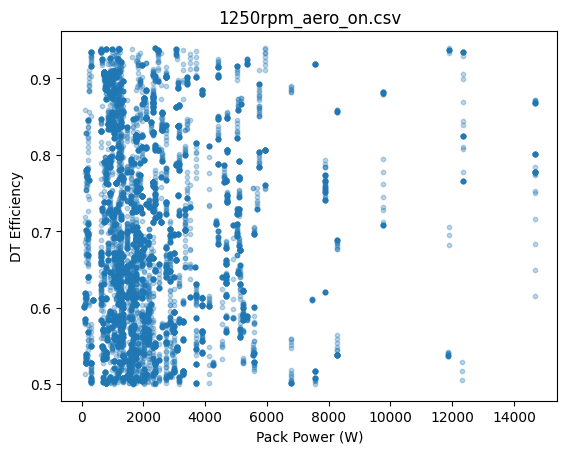

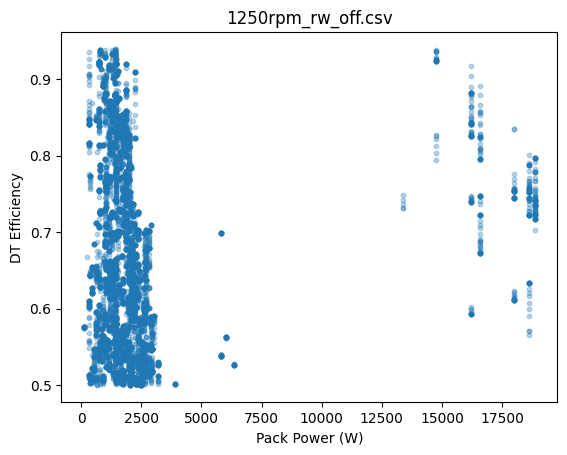

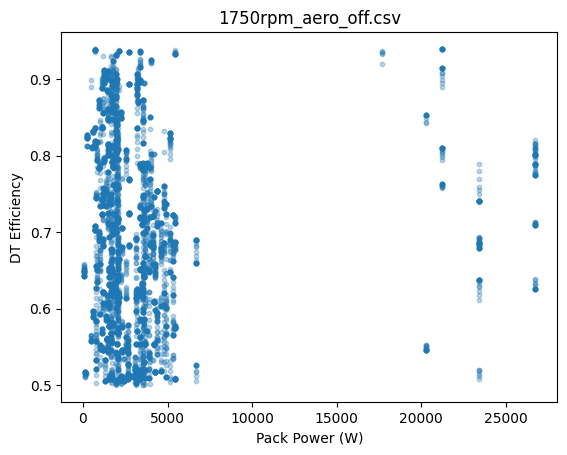

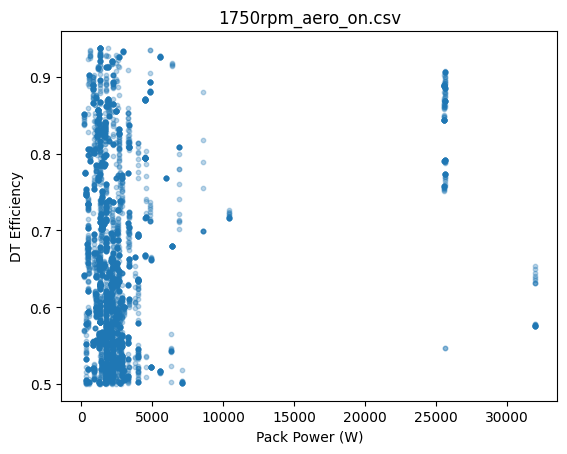

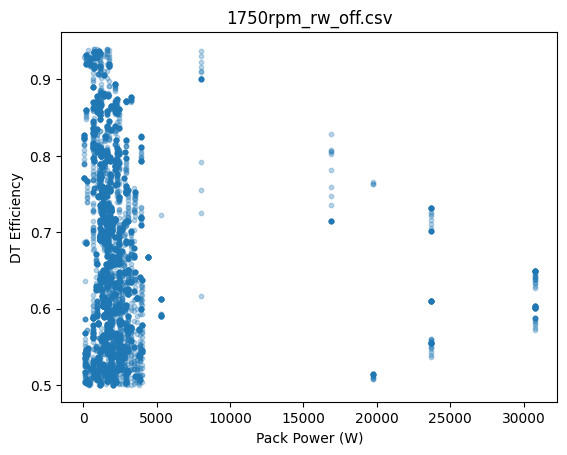

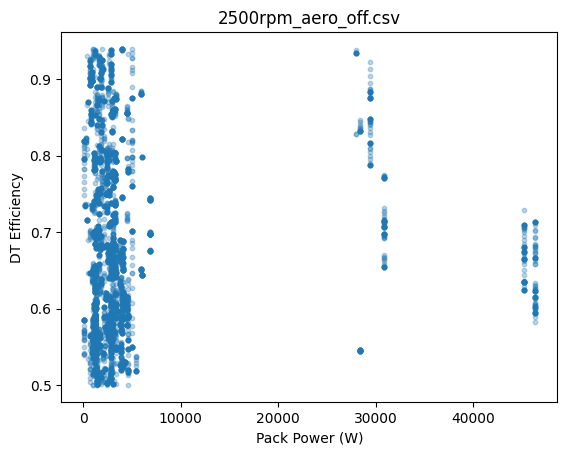

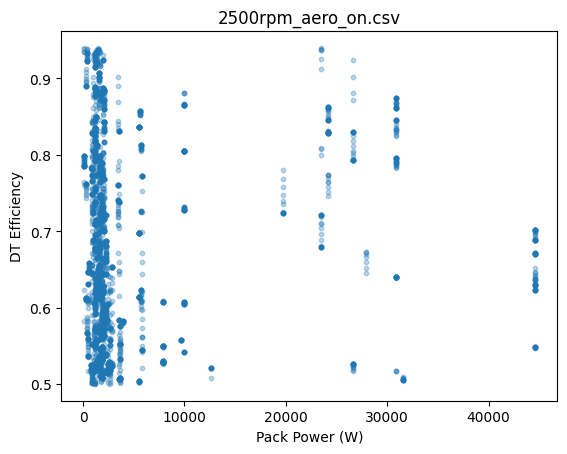

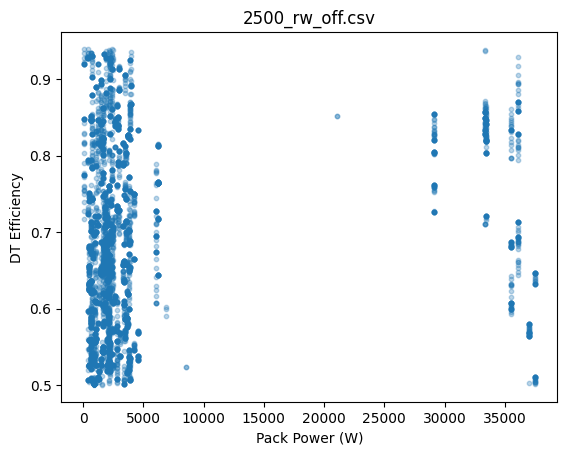

In [74]:
for name, df in df_dict.items():
    # work on a copy to avoid SettingWithCopyWarning
    df = df.copy()

    df['pack power'] = df['pack power'].abs()
    # calculate mechanical motor power
    df['motor power (w)'] = df['real torque'] * (df['motor rpm'] * ((2 * np.pi) / 60))

    # calculate efficiency based on mechanical power
    df['dt efficiency'] = df['motor power (w)'] / df['pack power']

    # drop the second half (temperatures too high)
    df = df.iloc[:len(df) // 2].copy()

    # drop cases below 50% and above 94%
    df['dt efficiency'] = df['dt efficiency'].abs()
    df = df[(df['dt efficiency'] >= 0.5) & (df['dt efficiency'] <= 0.94)].copy()

    df_dict[name] = df

    # plot
    plt.scatter(df['pack power'], df['dt efficiency'], s=10, alpha=0.3)
    plt.xlabel('Pack Power (W)')
    plt.ylabel('DT Efficiency')
    plt.title(name)
    plt.show()


### For this data, regression is overkill. We will use z-score to dynamically set bounds for pack power

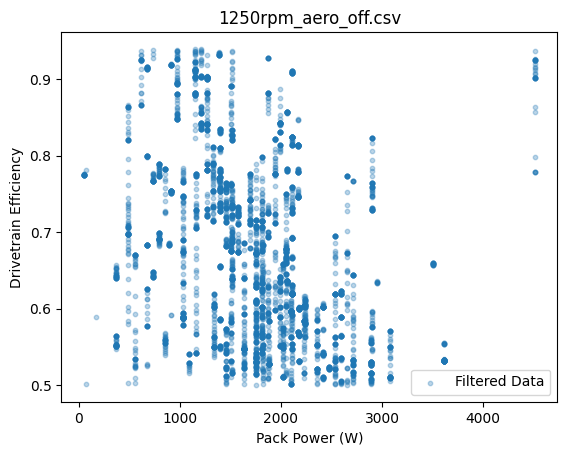

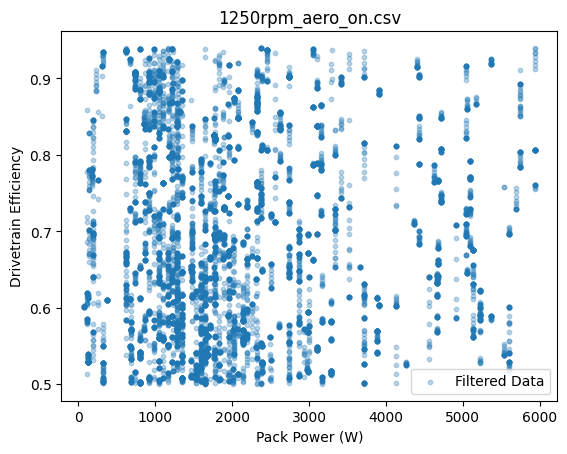

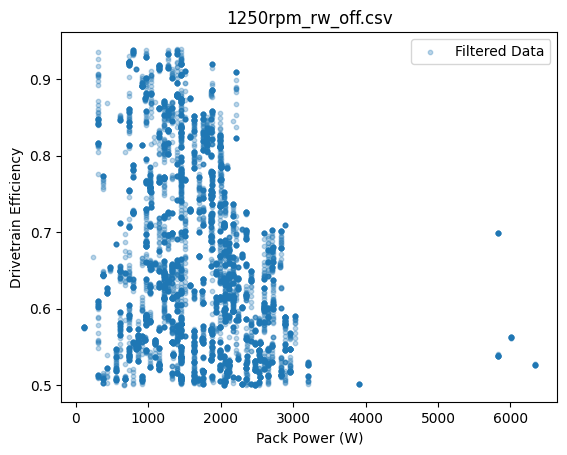

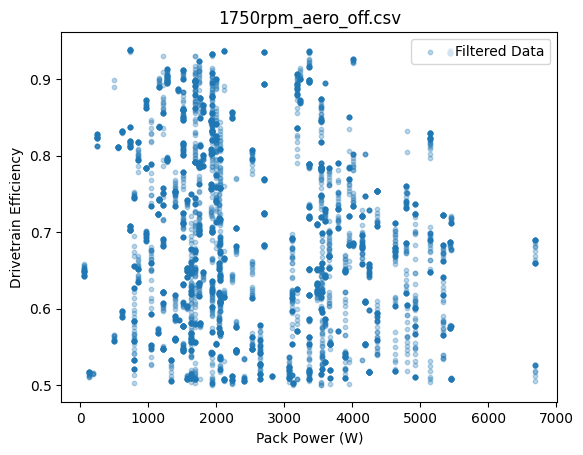

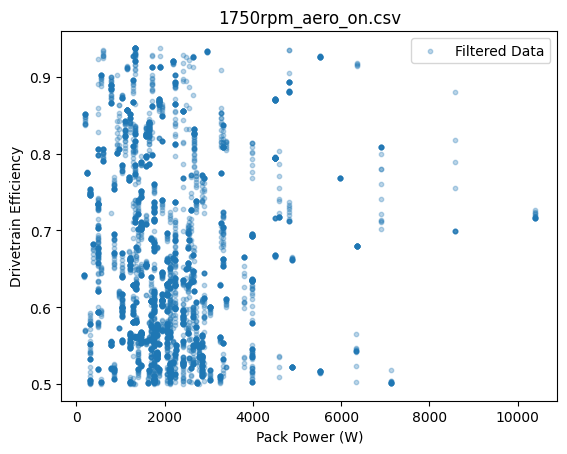

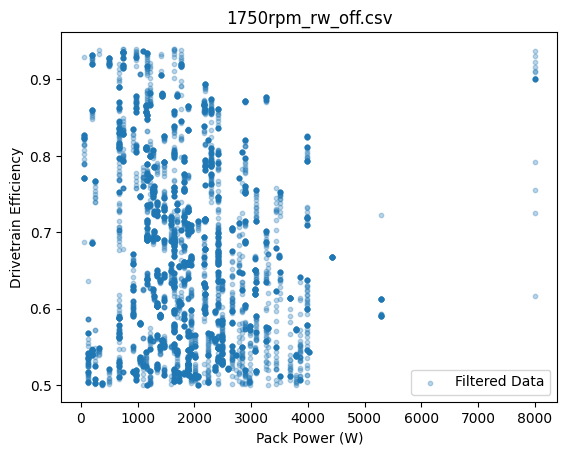

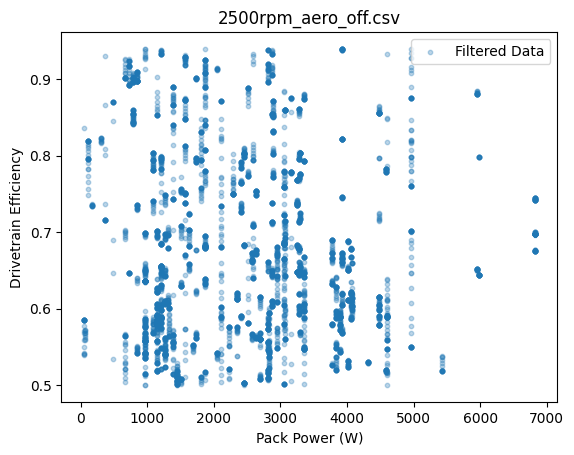

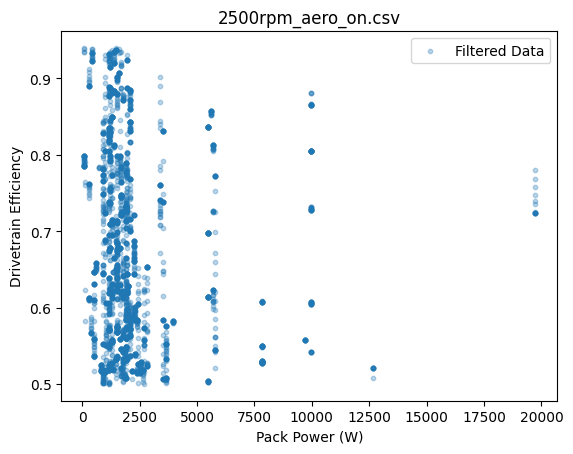

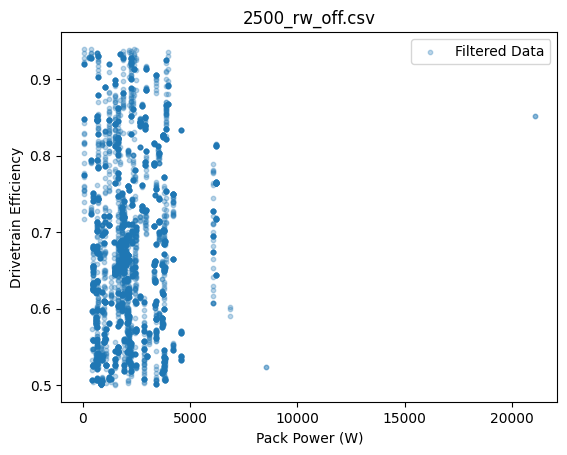

Mean efficiency: 67.33%


In [75]:
from scipy.stats import zscore

eta_list = []

for name, df in df_dict.items():
    df = df.copy()

    # compute z-scores for power
    df['z'] = zscore(df['pack power'], nan_policy='omit')

    # keep rows within 2 standard devs
    df = df[np.abs(df['z']) <= 2].copy()

    # extract filtered data
    x = df['pack power']
    y = df['dt efficiency']

    # plot
    plt.figure()
    plt.scatter(x, y, s=10, alpha=0.3, label='Filtered Data')
    plt.xlabel('Pack Power (W)')
    plt.ylabel('Drivetrain Efficiency')
    plt.title(name)
    plt.legend()
    plt.show()

    # print mean efficiency of filtered data
    mean_eta = y.mean()
    eta_list.append(mean_eta)

mean_eta_val = sum(eta_list)/len(eta_list)
print(f'Mean efficiency: {(mean_eta_val * 100):.2f}%')

### A final conversion efficiency of ~67% supports concerning findings, actually may be worse....damn
